# Introoduccion a Naive Bayes

- ¿lleva poco tiempo como cliente?
- ¿ Tiene un contrato mes a mes?
- ¿ paga mucho por el servicio?
- ¿ ha llamado muchas veces a soporte?


## ¿ porque se llama "Naive" (ingenuo)?

El modelo asume que **todas las variables** son independientes entre si. Es decir que asume que:

- El tipo de contrato No influye en el gasto mensual
- La antiguedad NO influye en si tiene un soporte técnico
- el genero NO influye sobre el método de pago

In [10]:
# importar librerias
import pandas as pd
import numpy as np 
import matplotlib.pyplot as pyplot
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score)

sns.set_style("whitegrid")
np.random.seed(42)

In [11]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Dataset: {len(df)} clientes")
print(f"Churn: {df['Churn'].mean()*100:.1f}%")

Dataset: 7032 clientes
Churn: 26.6%


In [12]:
# Codificar variables categóricas
df_encoded = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns, drop_first=True)

# Separar características y variable objetivo (X e y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )


# Escalar los datos

scaler = StandardScaler()
X_train =  pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Datos de entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros")
print(f"Variables: {X_train.shape[1]}")

Datos de entrenamiento: 5625 registros
Prueba: 1407 registros
Variables: 30


C:\Users\WilRussi\AppData\Local\Temp\ipykernel_7400\1262079730.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_encoded = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns, drop_first=True)


In [14]:
import time

In [15]:
# Entrenar Naive Bayes y medir el tiempo

inicio = time.time()
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)
tiempo_entrenamiento = time.time() - inicio

print(f"Modelo entrenado en {tiempo_entrenamiento*1000:.2f} ms")
print(f"\nClases aprendidas: {modelo_nb.classes_}")
print(f"Probabilidad base de cada clase:")
print(f" Permanece (0): {modelo_nb.class_prior_[0]*100:.1f}%")
print(f" Abandona (1): {modelo_nb.class_prior_[1]*100:.1f}%")

Modelo entrenado en 17.38 ms

Clases aprendidas: [0 1]
Probabilidad base de cada clase:
 Permanece (0): 73.4%
 Abandona (1): 26.6%


In [16]:
# Hacer predicciones
y_pred = modelo_nb.predict(X_test)

# Evaluar
print("RESULTADOS DE NAIVE BAYES")
print("="*50)
print(f" Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f" Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f" Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f" F1-Score: {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"{classification_report(y_test, y_pred, target_names=['Permanece (0)', 'Abandona (1)'], zero_division=0)}")

RESULTADOS DE NAIVE BAYES
 Accuracy: 0.6446
 Precision: 0.4184
 Recall: 0.8636
 F1-Score: 0.5637
               precision    recall  f1-score   support

Permanece (0)       0.92      0.57      0.70      1033
 Abandona (1)       0.42      0.86      0.56       374

     accuracy                           0.64      1407
    macro avg       0.67      0.71      0.63      1407
 weighted avg       0.79      0.64      0.66      1407



In [18]:
import matplotlib.pyplot as plt

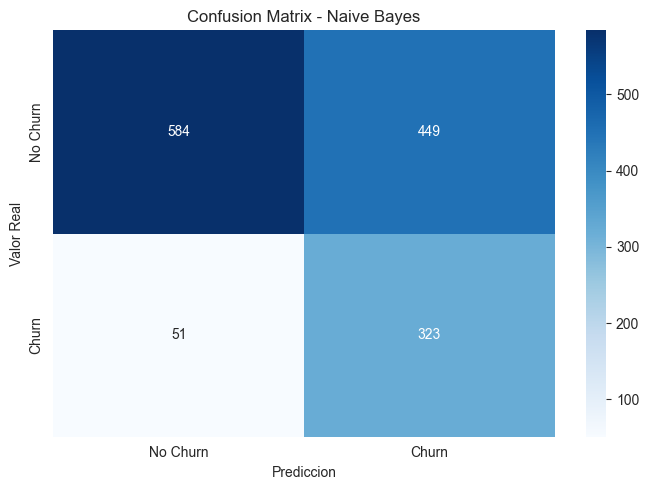


Interpretacion:
  Clientes que NO se fueron y el modelo acerto (TN): 584
  Clientes que NO se fueron pero el modelo dijo que si (FP): 449
  Clientes que SI se fueron pero el modelo no los detecto (FN): 51
  Clientes que SI se fueron y el modelo los detecto (TP): 323
Primeros 10 clientes con sus probabilidades:
(El modelo predice Churn cuando Prob_Churn > 0.5)


,Prob_No_Churn,Prob_Churn,Prediccion,Valor_Real
0,1.0000,0.0000,0,0
1,0.0000,1.0000,1,0
2,1.0000,0.0000,0,0
3,1.0000,0.0000,0,1
4,1.0000,0.0000,0,0
5,0.0006,0.9994,1,1
6,1.0000,0.0000,0,0
7,1.0000,0.0000,0,0
8,0.0001,0.9999,1,1
9,1.0000,0.0000,0,0


In [19]:
# Visualizar la matriz de confusion
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
ax.set_title('Confusion Matrix - Naive Bayes')
ax.set_ylabel('Valor Real')
ax.set_xlabel('Prediccion')

plt.tight_layout()
plt.show()

# Interpretar los numeros
tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretacion:")
print(f"  Clientes que NO se fueron y el modelo acerto (TN): {tn}")
print(f"  Clientes que NO se fueron pero el modelo dijo que si (FP): {fp}")
print(f"  Clientes que SI se fueron pero el modelo no los detecto (FN): {fn}")
print(f"  Clientes que SI se fueron y el modelo los detecto (TP): {tp}")
# Obtener las probabilidades de cada prediccion
probabilidades = modelo_nb.predict_proba(X_test)

# Crear un DataFrame con los resultados
df_proba = pd.DataFrame({
    'Prob_No_Churn': probabilidades[:, 0],
    'Prob_Churn': probabilidades[:, 1],
    'Prediccion': y_pred,
    'Valor_Real': y_test.values
})

print("Primeros 10 clientes con sus probabilidades:")
print("(El modelo predice Churn cuando Prob_Churn > 0.5)")
df_proba.head(10).round(4)
